# HW 6
## Minh Truong
## 1412225

Perform the following activities in Python:  

1. Get the dataset from the Naive Bayes Dataset folder:
2. Load the .csv file into a data frame in Python.
3. Describe the data, provide information on the dataset.
4. Conduct Gaussian Naive Bayes Classification
5. Train the model using the training dataset.
6. Split the list of labels accordingly.
7. Create a confusion matrix to compare the predicted state activities to the actual activities and compute the accuracy.
8. Make Predictions
9. Evaluate the model
10. Generate relevant graphs

# Import Packages

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, ConfusionMatrixDisplay, roc_curve, auc

## Get the dataset from the Naive Bayes Dataset folder:

I chose the Naive-Bayes-Classification-Data.csv dataset.

## Load the .csv file into a data frame in Python.

In [8]:
# Load Data
df = pd.read_csv('Naive-Bayes-Classification-Data.csv')

## Describe the data, provide information on the dataset.

In [37]:
# Displays the first few rows of the dataset
df.head()

,glucose,bloodpressure,diabetes
0,40,85,0
1,40,92,0
2,45,63,1
3,45,80,0
4,40,73,1


In [10]:
# Check data types
df.dtypes

glucose          int64
bloodpressure    int64
diabetes         int64
dtype: object

In [11]:
# Check for missing values
df.isnull().sum()

glucose          0
bloodpressure    0
diabetes         0
dtype: int64

In [12]:
# Descriptive statistics of the full dataset
df.describe()

,glucose,bloodpressure,diabetes
count,995.000000,995.000000,995.000000
mean,44.306533,79.184925,0.500503
std,6.707567,9.340204,0.500251
min,20.000000,50.000000,0.000000
25%,40.000000,72.000000,0.000000
50%,45.000000,80.000000,1.000000
75%,50.000000,87.000000,1.000000
max,70.000000,100.000000,1.000000


## Conduct Gaussian Naive Bayes Classification

In [18]:
# Define features and target
features = ['glucose', 'bloodpressure']
target = 'diabetes'

X = df[features]
y = df[target]

### Split the list of labels accordingly.

In [38]:
# Split data into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

### Train the model using the training dataset.

In [39]:
# Train Gaussian Naive Bayes model and generate predictions
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)

## Create a confusion matrix to compare the predicted state activities to the actual activities and compute the accuracy.

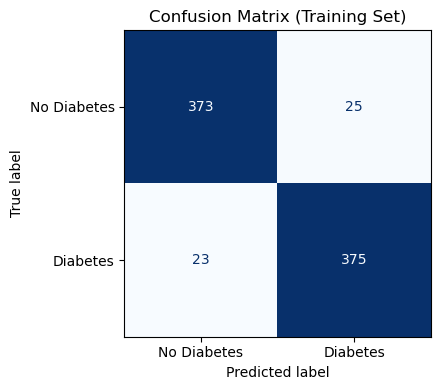

In [40]:
# Confusion Matrix on training set
y_pred_train = gnb.predict(X_train)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train),
                       display_labels=['No Diabetes', 'Diabetes']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix (Training Set)')
plt.tight_layout()
plt.show()

In [44]:
# Accuracy score of training set
accuracy_score(y_train, y_pred_train)

0.9396984924623115

## Make Predictions

In [45]:
# Predict on the test set
y_pred = gnb.predict(X_test)

## Evaluate the model

In [46]:
# Accuracy score of test set
accuracy_score(y_test, y_pred)

0.9095477386934674

In [47]:
# Precision, recall, and F1-score per class
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

              precision    recall  f1-score   support

 No Diabetes       0.91      0.91      0.91        99
    Diabetes       0.91      0.91      0.91       100

    accuracy                           0.91       199
   macro avg       0.91      0.91      0.91       199
weighted avg       0.91      0.91      0.91       199



## Generate relevant graphs

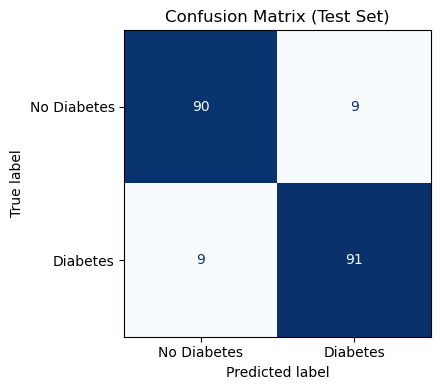

In [48]:
# Confusion Matrix on test set: Correct vs Incorrect predictions
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=['No Diabetes', 'Diabetes']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

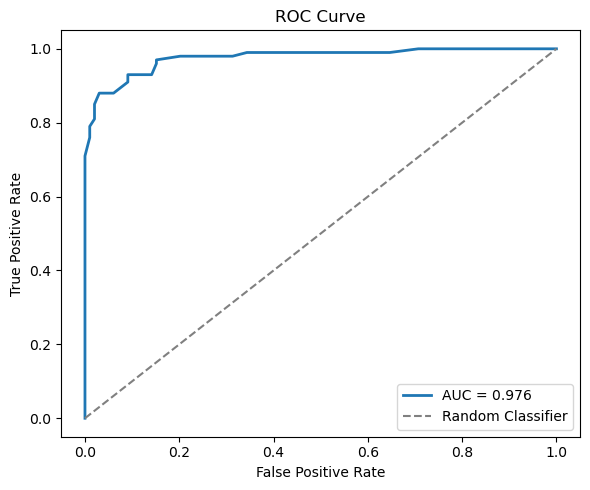

In [49]:
# ROC Curve measures the model's ability to separate classes (FP, TP, FN, TN)
y_proba = gnb.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Random Classifier')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

**Conclusion:**

The Gaussian Naive Bayes model performed well on this dataset, achieving high accuracy with blood pressure being the dominant predictor of diabetes classification.